# Business Problem

Credit card fraud results in significant financial losses for banks and payment processors.

The objective of this project is to build a machine learning model capable of identifying fraudulent transactions while minimizing false alarms.

Since fraud transactions are extremely rare, the dataset is highly imbalanced, making accuracy an unreliable evaluation metric.

The project compares multiple machine learning approaches to determine the most suitable production model.

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

p:\Data Science Learning\8 Live\Data-Science-Lab\projects\01_credit_card_fraud_detection


In [3]:
from src.data.download_data import download_dataset
import pandas as pd


In [4]:
dataset_path = download_dataset()

df = pd.read_csv(dataset_path)

df.head()

Dataset already exists.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
X = df.drop(columns="Class")

y = df["Class"]

## Dataset

Source:
Kaggle Credit Card Fraud Detection Dataset

Rows:
284,807

Features:
30

Target:
Class

0 → Legitimate

1 → Fraud

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
# The stratify parameter in data science ensures that when you divide a dataset (such as a training and testing split), 
# the subsets maintain the exact same proportion of classes as the original dataset. 
# It is primarily used in classification tasks—like the train_test_split function in scikit-learn—to prevent biased splits,
# especially when dealing with imbalanced datasets.

# Even though the dataset is large, we don't want to rely on chance. More generally,
# stratification preserves the class proportions in both the training and test sets, making evaluation more stable and representative.

In [7]:
print(y.value_counts(normalize=True))

print()

print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])

X_test["Amount"] = scaler.transform(X_test[["Amount"]])

Logistic Regression was selected as the baseline model because it is simple, interpretable, and provides a benchmark against which more complex models can be evaluated.

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",50000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [10]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9991573329588147
Precision: 0.8205128205128205
Recall   : 0.6530612244897959
F1 Score : 0.7272727272727273
ROC AUC  : 0.9514593717340623


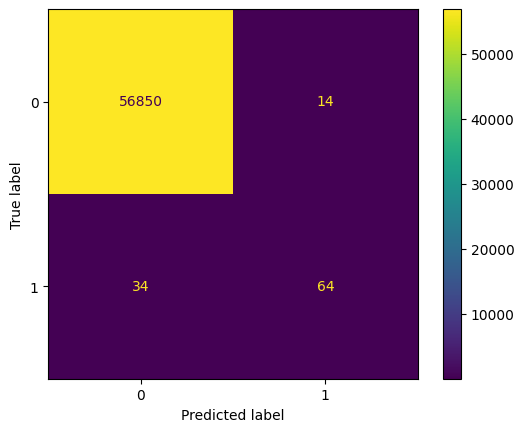

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56850    14]
 [   34    64]]


Observation

The model achieved high precision but relatively low recall, indicating that many fraudulent transactions remained undetected.

In [15]:
pd.DataFrame(
    {
        "Actual": y_test,
        "Probability": y_prob,
        "Prediction": y_pred,
    }
).head(20)

,Actual,Probability,Prediction
263020,0,3.494451e-05,0
11378,0,2.053808e-05,0
147283,0,3.840815e-07,0
219439,0,1.256044e-04,0
36939,0,8.803074e-03,0
243438,0,2.131488e-04,0
259448,0,2.044563e-05,0
43800,0,1.511801e-04,0
66742,0,7.961691e-04,0
66499,0,2.389931e-05,0


In [16]:
results = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_prob,
    "Prediction": y_pred
})

results[results["Actual"] == 1].sort_values(
    by="Probability",
    ascending=False
).head(20)

,Actual,Probability,Prediction
151008,1,1.000000,1
153835,1,1.000000,1
151519,1,1.000000,1
43428,1,1.000000,1
42756,1,1.000000,1
8615,1,1.000000,1
42769,1,1.000000,1
11343,1,1.000000,1
150647,1,1.000000,1
42549,1,1.000000,1


In [17]:
results[results["Actual"] == 1].sort_values(
    by="Probability",
    ascending=True
).head(20)

,Actual,Probability,Prediction
72757,1,0.000018,0
96341,1,0.000085,0
157585,1,0.000091,0
119714,1,0.000144,0
157918,1,0.000185,0
219025,1,0.000188,0
10497,1,0.000201,0
50537,1,0.000253,0
68067,1,0.000687,0
245347,1,0.001242,0


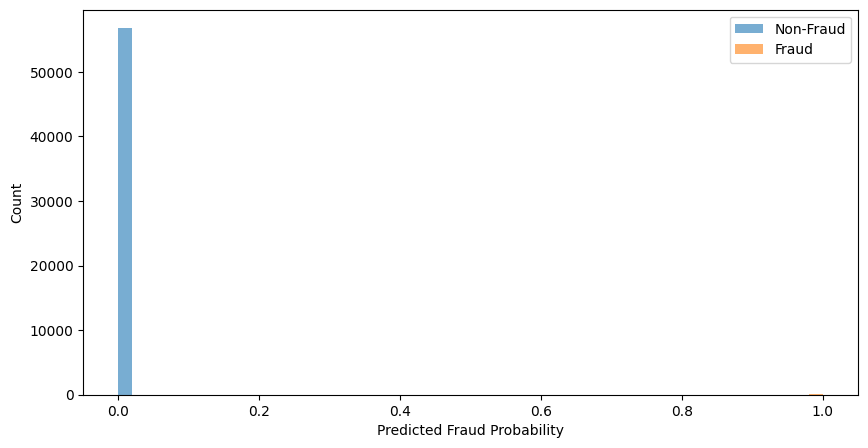

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    results[results["Actual"]==0]["Probability"],
    bins=50,
    alpha=0.6,
    label="Non-Fraud"
)

plt.hist(
    results[results["Actual"]==1]["Probability"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    print(f"Threshold: {t:.1f}")

    print("Precision:", round(precision_score(y_test,pred),3))

    print("Recall   :", round(recall_score(y_test,pred),3))

    print("F1       :", round(f1_score(y_test,pred),3))

    print("-"*40)

Threshold: 0.1
Precision: 0.71
Recall   : 0.776
F1       : 0.741
----------------------------------------
Threshold: 0.2
Precision: 0.737
Recall   : 0.745
F1       : 0.741
----------------------------------------
Threshold: 0.3
Precision: 0.737
Recall   : 0.714
F1       : 0.725
----------------------------------------
Threshold: 0.4
Precision: 0.77
Recall   : 0.684
F1       : 0.724
----------------------------------------
Threshold: 0.5
Precision: 0.821
Recall   : 0.653
F1       : 0.727
----------------------------------------
Threshold: 0.6
Precision: 0.829
Recall   : 0.643
F1       : 0.724
----------------------------------------
Threshold: 0.7
Precision: 0.847
Recall   : 0.622
F1       : 0.718
----------------------------------------
Threshold: 0.8
Precision: 0.828
Recall   : 0.541
F1       : 0.654
----------------------------------------


In [20]:
results = []

for threshold in [0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50]:

    prediction = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test,prediction),
        "Recall": recall_score(y_test,prediction),
        "F1": f1_score(y_test,prediction)
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.710280,0.775510,0.741463
1,0.15,0.732673,0.755102,0.743719
2,0.20,0.737374,0.744898,0.741117
3,0.25,0.734694,0.734694,0.734694
4,0.30,0.736842,0.714286,0.725389
5,0.35,0.747253,0.693878,0.719577
6,0.40,0.770115,0.683673,0.724324
7,0.45,0.822785,0.663265,0.734463
8,0.50,0.820513,0.653061,0.727273


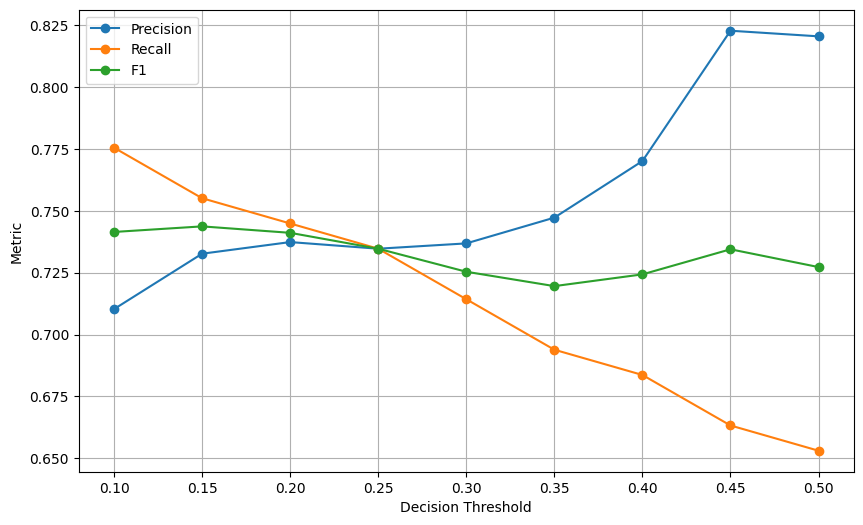

In [21]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric")

plt.grid(True)

plt.legend()

plt.show()

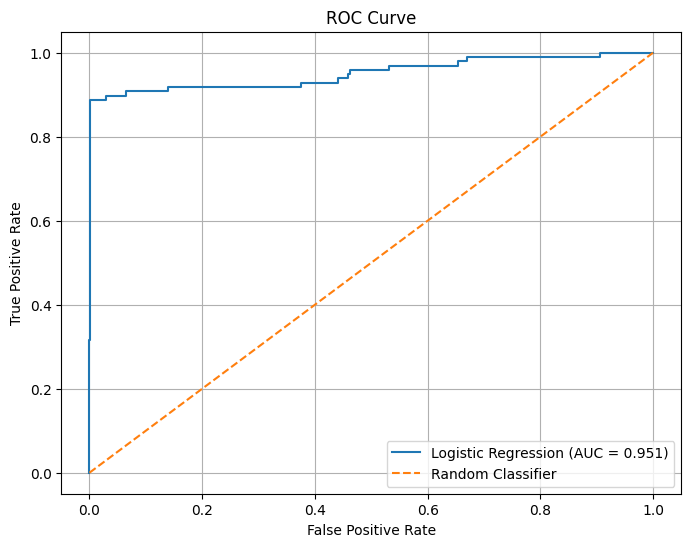

In [22]:
# How good is the model across all possible thresholds

from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()


Observation

The ROC curve lies close to the top-left corner of the graph and remains well above the random classifier line throughout. The model achieved an ROC-AUC of 0.951, indicating excellent discrimination between fraudulent and legitimate transactions.

Technical Interpretation

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different decision thresholds.

An AUC score of 0.951 means that if we randomly select one fraudulent transaction and one legitimate transaction, there is approximately a 95.1% probability that the model will assign a higher fraud probability to the fraudulent transaction than to the legitimate one.



From a business perspective, the model demonstrates a strong ability to prioritize suspicious transactions above genuine ones. This is particularly valuable in fraud detection, where investigators typically review only the highest-risk transactions.

Because the model ranks fraud cases effectively, the fraud operations team can adjust the decision threshold according to business requirements. For example:

If the business wants to minimize financial losses due to missed fraud, the threshold can be lowered to improve Recall, accepting more false alarms.
If investigation resources are limited, the threshold can be increased to reduce False Positives and improve Precision, even if some fraud cases are missed.

Limitations

Although the ROC curve indicates excellent ranking capability, it does not directly inform us whether the chosen operating threshold achieves the desired balance between Precision and Recall.

Since fraud detection is a highly imbalanced classification problem, additional analyses such as the Precision-Recall Curve and threshold tuning are required before selecting the final deployment threshold.

By lowering the threshold, we classify more transactions as fraud. This increases the number of frauds we detect (higher recall), but it also increases the number of legitimate transactions incorrectly flagged as fraud (higher false positives), which reduces precision.

In [23]:
class_weight="balanced"

In [47]:
model_b = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=50000
)

In [48]:
# We need model to improve Recall so that we can catch more fraud cases. 
# We will use class_weight="balanced" to give more weight to the minority class (fraud) during training.
# This should help the model focus more on correctly identifying fraudulent transactions, even if it means sacrificing some precision.

In [49]:
model_b.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",50000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default

In [50]:
y_pred_bal = model_b.predict(X_test)

y_prob_bal = model_b.predict_proba(X_test)[:,1]

In [51]:
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score )

print("Accuracy :", accuracy_score(y_test, y_pred_bal))

print("Precision:", precision_score(y_test, y_pred_bal))

print("Recall   :", recall_score(y_test, y_pred_bal))

print("F1 Score :", f1_score(y_test, y_pred_bal))

print("ROC AUC  :", roc_auc_score(y_test, y_prob_bal))

Accuracy : 0.9755275446789088
Precision: 0.06097560975609756
Recall   : 0.9183673469387755
F1 Score : 0.11435832274459974
ROC AUC  : 0.972017642524089


In [52]:
print(classification_report(y_test, y_pred_bal))

print(confusion_matrix(y_test, y_pred_bal))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_bal))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

[[55478  1386]
 [    8    90]]
ROC-AUC: 0.972017642524089


In [28]:
# The model has learned a better separation between classes (higher ROC-AUC), but the default decision threshold of 0.5 is no longer appropriate.

Using class_weight='balanced', the model significantly improved Recall from approximately 65% to 92%, indicating that it successfully identified a much larger proportion of fraudulent transactions. Additionally, the ROC-AUC increased from 0.951 to 0.972, suggesting that the model learned a better ranking between fraudulent and legitimate transactions.

However, Precision dropped substantially to approximately 6%, meaning a large number of legitimate transactions were incorrectly flagged as fraud. Consequently, the F1-score also decreased because F1 penalizes large imbalances between Precision and Recall.

Based on these results, I would not immediately reject the model. Instead, I would perform threshold tuning to determine whether a different decision threshold can achieve a more appropriate balance between fraud detection and investigation workload."

In [53]:
y_prob_balanced = model_b.predict_proba(X_test)[:, 1]

In [54]:

threshold_results = []

thresholds = [i/100 for i in range(5,96,5)]

for threshold in thresholds:

    y_pred = (y_prob_balanced >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.004987,0.959184,0.009923
1,0.10,0.008151,0.948980,0.016163
2,0.15,0.011955,0.948980,0.023613
3,0.20,0.016353,0.938776,0.032145
4,0.25,0.021231,0.918367,0.041503
5,0.30,0.027331,0.918367,0.053082
6,0.35,0.034247,0.918367,0.066031
7,0.40,0.042095,0.918367,0.080501
8,0.45,0.050819,0.918367,0.096308
9,0.50,0.060976,0.918367,0.114358


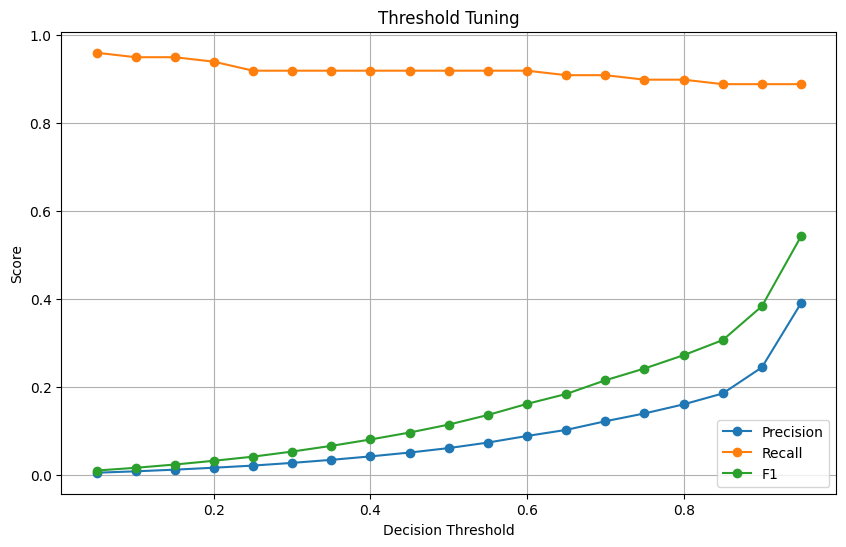

In [55]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")

plt.grid(True)

plt.legend()

plt.show()

In [56]:
best = threshold_df.loc[threshold_df["F1"].idxmax()]

best

Threshold    0.950000
Precision    0.390135
Recall       0.887755
F1           0.542056
Name: 18, dtype: float64

In [57]:
best_threshold = best["Threshold"]

y_pred_best = ( y_prob_balanced >= best_threshold ).astype(int)

In [58]:
results = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_prob,
    "Prediction": y_pred
})

results[results["Actual"] == 1].sort_values(
    by="Probability",
    ascending=False
).head(20)

,Actual,Probability,Prediction
151008,1,1.000000,1
153835,1,1.000000,1
151519,1,1.000000,1
43428,1,1.000000,1
42756,1,1.000000,1
8615,1,1.000000,1
42769,1,1.000000,1
11343,1,1.000000,1
150647,1,1.000000,1
42549,1,1.000000,1


In [59]:
results[results["Actual"] == 1].sort_values(
    by="Probability",
    ascending=True
).head(20)

,Actual,Probability,Prediction
72757,1,0.000018,0
96341,1,0.000085,0
157585,1,0.000091,0
119714,1,0.000144,0
157918,1,0.000185,0
219025,1,0.000188,0
10497,1,0.000201,0
50537,1,0.000253,0
68067,1,0.000687,0
245347,1,0.001242,0


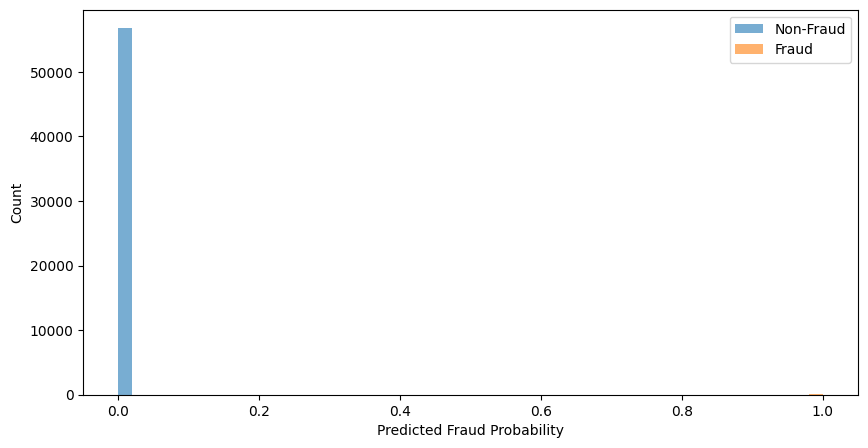

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    results[results["Actual"]==0]["Probability"],
    bins=50,
    alpha=0.6,
    label="Non-Fraud"
)

plt.hist(
    results[results["Actual"]==1]["Probability"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

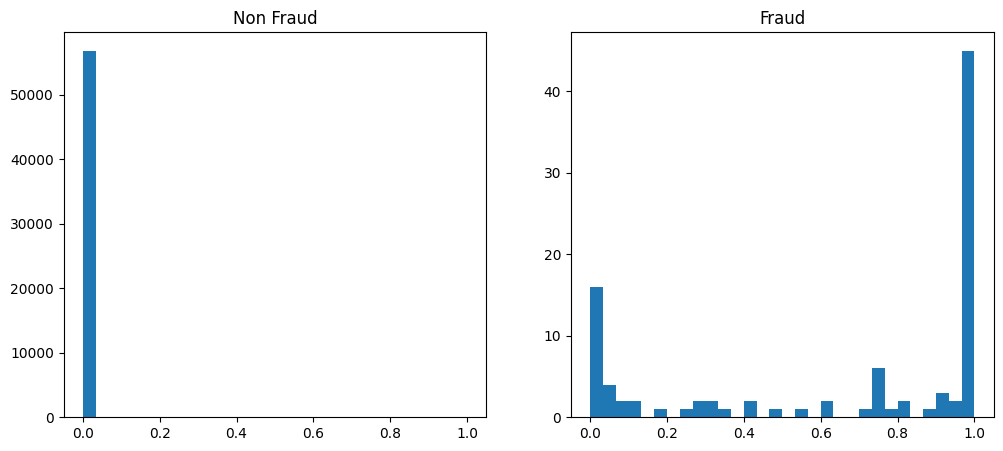

In [61]:
non_fraud_probs = results[results["Actual"]==0]["Probability"]

fraud_probs = results[results["Actual"]==1]["Probability"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(non_fraud_probs, bins=30)
plt.title("Non Fraud")

plt.subplot(1,2,2)
plt.hist(fraud_probs, bins=30)
plt.title("Fraud")

plt.show()

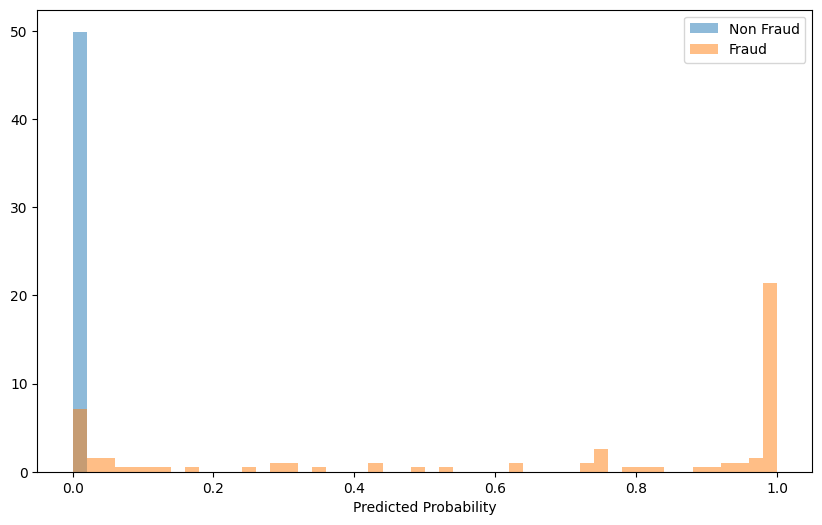

In [62]:
plt.figure(figsize=(10,6))

plt.hist(
    non_fraud_probs,
    bins=50,
    density=True,
    alpha=0.5,
    label="Non Fraud"
)

plt.hist(
    fraud_probs,
    bins=50,
    density=True,
    alpha=0.5,
    label="Fraud"
)

plt.legend()
plt.xlabel("Predicted Probability")
plt.show()

In [ ]:
# Simple Logistic Regression model : Caluclating with different threshold if we can find good Recall and Precision Score.


from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    print(f"Threshold: {t:.1f}")

    print("Precision:", round(precision_score(y_test,pred),3))

    print("Recall   :", round(recall_score(y_test,pred),3))

    print("F1       :", round(f1_score(y_test,pred),3))

    print("-"*40)

Threshold: 0.1
Precision: 0.71
Recall   : 0.776
F1       : 0.741
----------------------------------------
Threshold: 0.2
Precision: 0.737
Recall   : 0.745
F1       : 0.741
----------------------------------------
Threshold: 0.3
Precision: 0.737
Recall   : 0.714
F1       : 0.725
----------------------------------------
Threshold: 0.4
Precision: 0.77
Recall   : 0.684
F1       : 0.724
----------------------------------------
Threshold: 0.5
Precision: 0.821
Recall   : 0.653
F1       : 0.727
----------------------------------------
Threshold: 0.6
Precision: 0.829
Recall   : 0.643
F1       : 0.724
----------------------------------------
Threshold: 0.7
Precision: 0.847
Recall   : 0.622
F1       : 0.718
----------------------------------------
Threshold: 0.8
Precision: 0.828
Recall   : 0.541
F1       : 0.654
----------------------------------------


In [64]:
from sklearn.metrics import confusion_matrix

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    print(f"\nThreshold {t}")

    print(f"TP : {tp}")
    print(f"FP : {fp}")
    print(f"FN : {fn}")
    print(f"TN : {tn}")


Threshold 0.1
TP : 76
FP : 31
FN : 22
TN : 56833

Threshold 0.2
TP : 73
FP : 26
FN : 25
TN : 56838

Threshold 0.3
TP : 70
FP : 25
FN : 28
TN : 56839

Threshold 0.4
TP : 67
FP : 20
FN : 31
TN : 56844

Threshold 0.5
TP : 64
FP : 14
FN : 34
TN : 56850

Threshold 0.6
TP : 63
FP : 13
FN : 35
TN : 56851

Threshold 0.7
TP : 61
FP : 11
FN : 37
TN : 56853

Threshold 0.8
TP : 53
FP : 11
FN : 45
TN : 56853


The default threshold of 0.5 is arbitrary. I would select a threshold based on the business objective. In fraud detection, missing a fraudulent transaction is usually more costly than reviewing a legitimate one, so I would evaluate Precision-Recall trade-offs across multiple thresholds, examine the confusion matrix, and choose the operating point that minimizes the expected business cost rather than simply maximizing accuracy.

In [ ]:
# for the balanced model, we will calculate the metrics for different thresholds and store them in a DataFrame for better visualization.

import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

results = []

for t in thresholds:

    pred = (y_prob_bal >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append({
        "Threshold": t,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

results_df = pd.DataFrame(results)

results_df

,Threshold,TP,FP,FN,TN,Precision,Recall,F1
0,0.1,93,11317,5,45547,0.008151,0.948980,0.016163
1,0.2,92,5534,6,51330,0.016353,0.938776,0.032145
2,0.3,90,3203,8,53661,0.027331,0.918367,0.053082
3,0.4,90,2048,8,54816,0.042095,0.918367,0.080501
4,0.5,90,1386,8,55478,0.060976,0.918367,0.114358
5,0.6,90,927,8,55937,0.088496,0.918367,0.161435
6,0.7,89,641,9,56223,0.121918,0.908163,0.214976
7,0.8,88,461,10,56403,0.160291,0.897959,0.272025


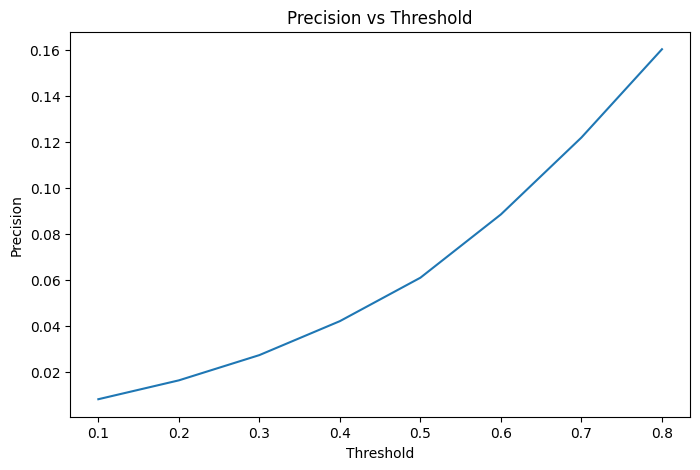

In [72]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"]
)

plt.xlabel("Threshold")

plt.ylabel("Precision")

plt.title("Precision vs Threshold")
plt.show()

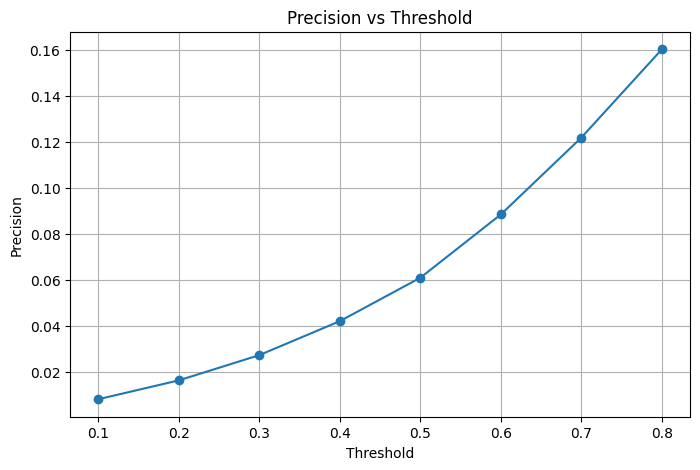

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker='o'
)

plt.title("Precision vs Threshold")

plt.xlabel("Threshold")

plt.ylabel("Precision")

plt.grid(True)

plt.show()

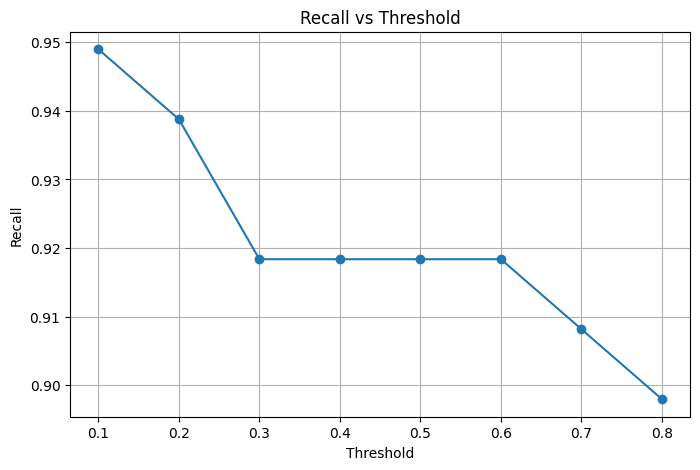

In [74]:
# Recall 

plt.figure(figsize=(8,5))

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker='o'
)

plt.title("Recall vs Threshold")

plt.xlabel("Threshold")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

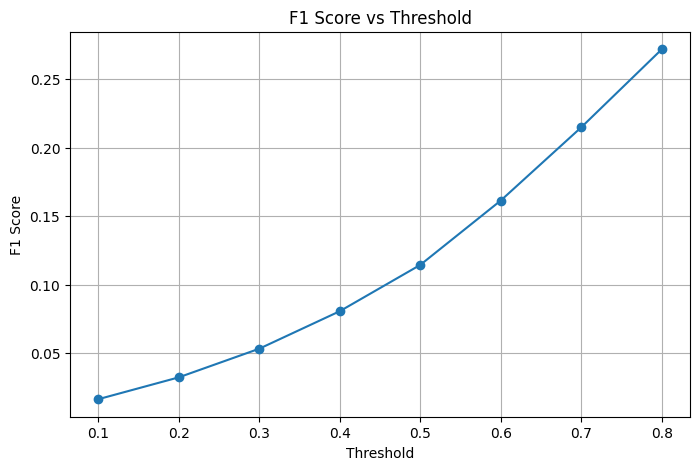

In [75]:
# F1 Score
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Threshold"],
    results_df["F1"],
    marker='o'
)

plt.title("F1 Score vs Threshold")

plt.xlabel("Threshold")

plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

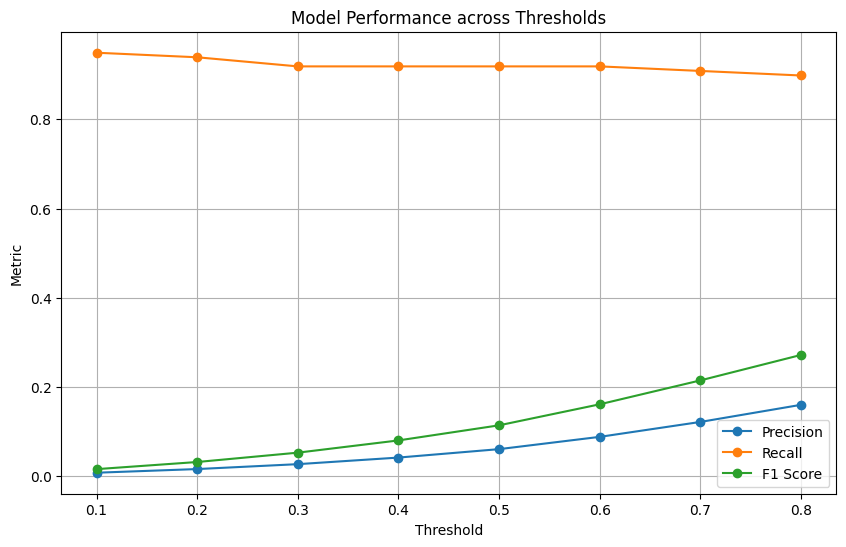

In [76]:
plt.figure(figsize=(10,6))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    results_df["Threshold"],
    results_df["F1"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Metric")

plt.title("Model Performance across Thresholds")

plt.legend()

plt.grid(True)

plt.show()

Precision increases steadily as the threshold increases because the model becomes more selective, reducing false positives.
Recall remains high (around 0.90–0.95), meaning the model continues to identify most fraudulent transactions even with stricter thresholds.
F1 score also increases in this range because the reduction in false positives outweighs the small increase in false negatives.

Most fraud transactions receive very high predicted probabilities from the model. Therefore, even as we increase the threshold, the majority of fraud cases still remain above the threshold and continue to be classified correctly. As a result, the number of True Positives decreases only slightly, causing Recall to remain almost constant.

On the other hand, many legitimate transactions receive moderate probabilities (for example between 0.1 and 0.8). Increasing the threshold removes a large number of these false alarms, causing False Positives to decrease dramatically. Since Precision depends heavily on False Positives, Precision improves significantly.

In our results:

Threshold 0.6
TP = 90
FP = 927
FN = 8
Threshold 0.8
TP = 88
FP = 461
FN = 10

By increasing the threshold from 0.6 to 0.8, we reduce the investigation workload by 466 transactions but miss 2 additional fraud cases.

If each missed fraud costs the business $5,000, then those two additional missed frauds represent an expected loss of $10,000.

Therefore, if investigating 466 extra transactions costs less than $10,000, threshold 0.6 would be the better business decision.

Conversely, if manual investigations are extremely expensive, threshold 0.8 may be preferable.

Our dataset is highly imbalanced, with fraud transactions representing a very small fraction of the data. During training, a standard Logistic Regression treats mistakes on both classes equally, so it tends to favor the majority class. By using class_weight='balanced', the loss function assigns a higher penalty to mistakes on fraud transactions. This encourages the model to detect more fraud cases, typically increasing recall, although it may also increase false positives and reduce precision. Whether this trade-off is desirable depends on the business cost of missed fraud versus manual investigations.

In [77]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [78]:
N = len(y_train)
K = 2

weight_0 = N / (K * y_train.value_counts()[0])
weight_1 = N / (K * y_train.value_counts()[1])

print(weight_0)
print(weight_1)

0.5008661206149896
289.14340101522845


The balanced Logistic Regression achieved high recall at the default threshold but generated too many false positives. Based on the fraud team's estimated investigation capacity, a threshold of 0.7 was selected for deployment. This reduced daily alerts while still maintaining approximately 91% recall, making it a more practical operating point.

In [79]:
class FraudDetector:

    def __init__(self, model, threshold=0.7):
        self.model = model
        self.threshold = threshold

    def predict(self, X):

        # Get probability of fraud
        prob = self.model.predict_proba(X)[:, 1]

        # Apply custom threshold
        return (prob >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]

In [80]:
fraud_model = FraudDetector(
    model=model_b,
    threshold=0.70
)

In [81]:
# Predictions using threshold = 0.70

y_pred_custom = fraud_model.predict(X_test)

# Probabilities
y_prob_custom = fraud_model.predict_proba(X_test)

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_custom)

print(cm)

[[56223   641]
 [    9    89]]


## SMOTE 

In [86]:
!pip install imbalanced-learn

   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   ---------------------------------------  235.5/236.1 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 236.1/236.1 kB 4.8 MB/s eta 0:00:00


In [87]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

In [88]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [89]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


In [90]:
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=50000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",50000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [91]:
y_pred_smote = lr_smote.predict(X_test)

y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

In [92]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred_smote))

print(confusion_matrix(y_test, y_pred_smote))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_smote))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

[[56290   574]
 [   10    88]]
ROC-AUC: 0.9775688395082287


## Random Forest

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [94]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [95]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   17    81]]
ROC-AUC: 0.9623489414054873


##### Random Forest vs Logistic Regression

Logistic Regression assumes a linear relationship between the input features and the log-odds of the target. The credit card fraud dataset contains complex nonlinear interactions among the anonymized PCA features. Random Forest can model these nonlinear relationships by recursively partitioning the feature space using many decision trees. As a result, it achieved a much better balance between precision and recall while maintaining a very low false positive rate.

In [97]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

In [ ]:
## Applying Random Search CV to find the best hyperparameters for Random Forest Classifier
# In this we are optimising the F1 score.

from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichret

In [99]:
print(rf_search.best_params_)

{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}


In [100]:
best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56860     4]
 [   18    80]]
ROC-AUC: 0.9652027788464852


In [ ]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

   Feature  Importance
17     V17    0.155648
12     V12    0.132687
14     V14    0.115301
11     V11    0.074429
10     V10    0.072532
16     V16    0.069218
9       V9    0.043184
4       V4    0.036347
18     V18    0.032618
7       V7    0.025885
3       V3    0.019619
26     V26    0.017897
21     V21    0.016076
6       V6    0.014353
1       V1    0.013969


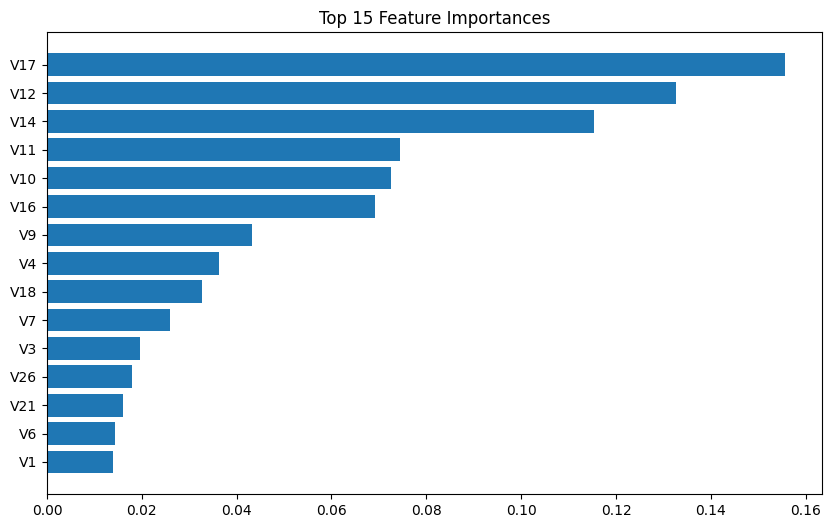

In [102]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances")

plt.show()

Random Forest improved both precision and recall by modeling nonlinear relationships within the data.

Compared with Logistic Regression, the model significantly reduced false negatives while maintaining a very low false positive rate.

# XGBoost

In [105]:
!pip install xgboost

In [106]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [107]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56852    12]
 [   17    81]]
ROC-AUC: 0.9789705907686653


In [108]:
y_prob = xgb.predict_proba(X_test)[:, 1]

threshold = 0.7

y_pred = (y_prob >= threshold).astype(int)

If Random Forest has a better F1-score, why might a company still choose XGBoost?


Although Random Forest achieved a slightly higher F1-score on this test set, XGBoost produced a higher ROC-AUC, indicating better probability ranking across different thresholds. In production, where decision thresholds may change based on business requirements or operational capacity, XGBoost's stronger ranking ability can make it more flexible and effective.

XGBoost achieved the highest ROC-AUC, demonstrating excellent ranking ability across different decision thresholds.

Although its F1-score was slightly lower than the tuned Random Forest, it provides high-quality probability estimates, making it attractive for production systems that rely on configurable thresholds.

In [109]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
}

In [110]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [111]:
print(search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [112]:
best_xgb = search.best_estimator_

In [113]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
14,V14,0.557382
4,V4,0.071075
12,V12,0.037759
10,V10,0.027948
20,V20,0.026193
26,V26,0.023687
7,V7,0.022708
29,Amount,0.022212
13,V13,0.020164
1,V1,0.018332


In [114]:
!pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ----------- ---------------------------- 153.6/554.9 kB 4.6 MB/s eta 0:00:01
   -------------------------------- ------- 450.6/554.9 kB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 554.9/554.9 kB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.4/12.6 MB 11.5 MB/s eta 0:00:02
   -- ------------------------------------- 0.8/12.6 MB 10.2 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/12.6 MB 10.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.9/12.6 MB 10.9 MB/s eta 0:00:01
   ------- -------------------------------- 2.5/12.6 MB 11.4 MB/s eta 0:00:01
   ---------- ----------------------------- 3.3/12.6 MB 12.4 MB/s eta 0:00:01
   ------------- -------------------------- 4.2/12.6 MB 13.5 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.6 MB 14.3 MB/s eta 0:0

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.1.1 requires numpy<2.0,>=1.16; python_version <= "3.11", but you have numpy 2.4.6 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.4.6 which is incompatible.


In [115]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

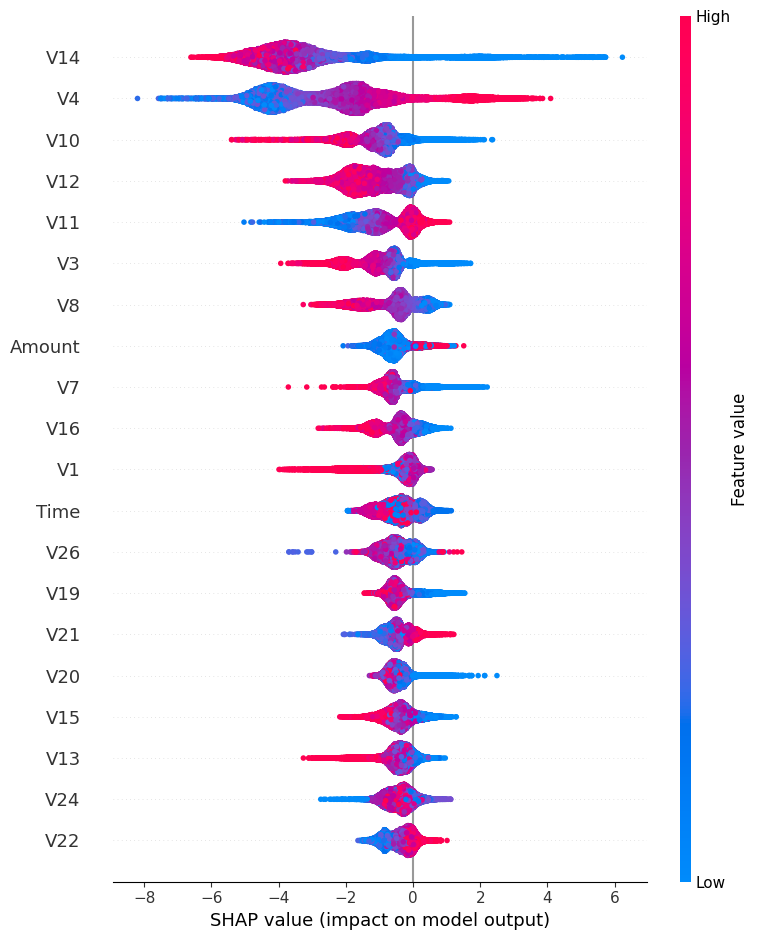

In [116]:
shap.summary_plot(
    shap_values,
    X_test
)

In [117]:
fraud_index = y_test[y_test == 1].index[0]

sample_position = X_test.index.get_loc(fraud_index)

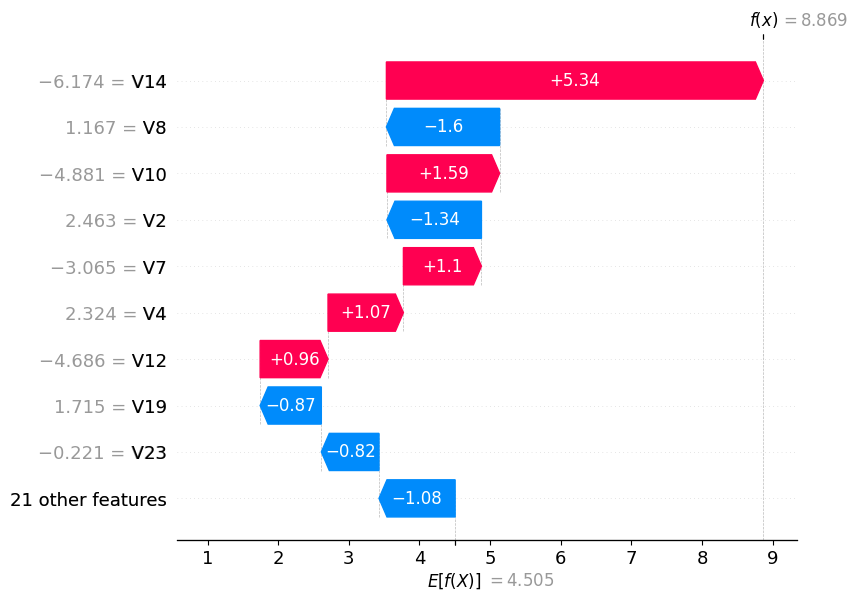

In [118]:
shap.plots.waterfall(
    explainer(X_test.iloc[[sample_position]])[0]
)

| Feature Importance                     | SHAP                                             |
| -------------------------------------- | ------------------------------------------------ |
| Global only                            | Global + Local                                   |
| Doesn't show direction                 | Shows positive/negative contribution             |
| Hard to explain individual predictions | Explains each prediction                         |
| Based on tree splits                   | Based on feature contributions to the prediction |


In [119]:
import joblib

joblib.dump(best_xgb, "../artifacts/xgboost_model.pkl")

['../artifacts/xgboost_model.pkl']

In [120]:
joblib.dump(scaler, "../artifacts/scaler.pkl")

['../artifacts/scaler.pkl']

In [121]:
import json

metadata = {
    "model": "XGBoost",
    "dataset": "Credit Card Fraud",
    "roc_auc": 0.979,
    "precision": 0.87,
    "recall": 0.83,
    "f1": 0.85,
    "features": list(X_train.columns)
}

with open("../artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# Business Recommendation 

For organizations prioritizing minimal manual investigations, the tuned Random Forest is an excellent choice due to its very high precision and low false positive rate. If the business requires configurable risk thresholds and probability-based decision making, XGBoost may be preferred because of its superior ROC-AUC and ranking performance.